### Importing Libraries
Importing essential data manipulation (`pandas`) and numerical computing (`numpy`) libraries.

In [65]:
import pandas as pd
import numpy as np

### 1. Data Loading and Inspection
Loading the **Real Estate Valuation dataset**

In [66]:
df = pd.read_excel("../Datasets/Real_estate_valuation.xlsx")

In [67]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### Column Renaming
Renaming raw dataset columns to clean, standardized snake_case identifiers to streamline matrix operations.

In [68]:
df = df.rename(columns={"X1 transaction date" : "transaction_date",
                        "X2 house age":"house_age",
                        "X3 distance to the nearest MRT station": "distance_to_mrt_station",
                        "X4 number of convenience stores": "no_of_convenience_stores",
                        "X5 latitude" : "latitude",
                        "X6 longitude" : "longitude",
                        "Y house price of unit area" : "Y_house_price_unit_area"})
df.head()

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### 2. Feature Extraction & Target Separation
Separating the input feature matrix $X$ from the target variable vector $Y$ (`Y_house_price_unit_area`) and reshaping $Y$ into a 2D column vector of shape `(414, 1)` for matrix multiplication compatibility.

In [69]:
X = df.drop("Y_house_price_unit_area",axis=1).to_numpy()
Y = df["Y_house_price_unit_area"].to_numpy().reshape(-1,1)
print(Y.shape)


(414, 1)


### Initializing Parameters
Defining the parameter initialization function to randomly generate the weight vector $W$ and bias term $b$.

In [70]:
def intialize_params(X):
    W = np.random.randn(X.shape[1],1)
    b = np.random.randn(1,1)
    return W, b

### Data Normalization
Implementing **Z-score normalization** to scale features and target values, stabilizing gradient descent optimization:
$$X_{scaled} = \frac{X - \mu}{\sigma}$$

In [71]:
def normalizing_data(X,Y):
    X_Scaled = (X - np.mean(X,axis=0, keepdims=True)) / np.std(X,axis=0,keepdims=True)
    Y_Scaled = (Y - np.mean(Y)) / np.std(Y)

    return X_Scaled, Y_Scaled

### Predict Function
Implementing the linear model prediction hypothesis using matrix multiplication:
$$\hat{Y} = XW + b$$

In [72]:
def predict(X,W,b):
    return X@W +b

### Cost Function (L1 Regularization - Lasso)
Computing the regularized cost using Mean Squared Error (MSE) combined with an **L1 Regularization penalty** ($\lambda \sum |W|$), which penalizes absolute weights and drives irrelevant feature coefficients to zero:
$$J(W, b) = \frac{1}{2n} \sum (\hat{Y} - Y)^2 + \frac{\lambda}{n} \sum |W|$$

In [73]:
def compute_cost(Y,Y_hat,lamda,W):
    n = Y.shape[0]
    return (1/(2*n))*np.sum((Y_hat - Y)**2) + ((lamda)*np.sum(np.abs(W)))

### Gradient Calculations
Calculating the analytical partial derivatives of the cost function with respect to weights ($dEdw$) and bias ($dEdb$), including the L1 penalty derivative term via `np.sign(W)`.

$$\frac{\partial J}{\partial W} = \frac{1}{n} X^T (\hat{Y} - Y) + \frac{\lambda}{n} \text{sign}(W)$$
$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum (\hat{Y} - Y)$$

In [74]:
def dEdw(X,Y,W,b,lamda):
    n = X.shape[0]
    Y_hat = predict(X,W,b)

    return (np.dot(X.T,Y_hat- Y)) / n + (lamda/n) * np.sign(W)
def dEdb(Y,W,X,b):
    Y_hat = predict(X,W,b)
    n = Y.shape[0]

    return np.sum(Y_hat -  Y) / n



### Gradient Descent Training Loop
Iterating through the specified epochs to perform gradient descent updates on weights and biases while tracking training loss convergence.

In [75]:
def train(X,Y,W,b,learning_rate = 0.001, lamda = 1, epochs = 100000):
    losses = []

    for epoch in range(epochs):
        dw = dEdw(X,Y,W,b,lamda)
        db = dEdb(Y,W,X,b)

        W = W - learning_rate * dw
        b = b - learning_rate * db

        Y_hat = predict(X,W,b)
        losses.append(compute_cost(Y,Y_hat,lamda,W))

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch}: Loss {losses[-1]}")
    return W, b, losses

### Procedural Training & Execution
Normalizing the dataset, initializing parameters, and running the procedural training loop to minimize regularized loss across epochs.

In [76]:
X_norm, Y_norm  = normalizing_data(X, Y)
W,b = intialize_params(X)
W


array([[-0.08651652],
       [ 0.71327356],
       [ 1.08878096],
       [ 0.29680478],
       [-0.46297129],
       [-1.02569955],
       [-2.22643974]])

In [77]:
W,b,losses= train(X_norm, Y_norm, W, b)

Epoch 0: Loss 15.378177554133426
Epoch 10: Loss 14.794917632094643
Epoch 20: Loss 14.237047741667137
Epoch 30: Loss 13.703357825833482
Epoch 40: Loss 13.1926981683256
Epoch 50: Loss 12.70397631614854
Epoch 60: Loss 12.236154160826116
Epoch 70: Loss 11.788245170136694
Epoch 80: Loss 11.359311762535391
Epoch 90: Loss 10.957038337205649
Epoch 100: Loss 10.62111570895857
Epoch 110: Loss 10.300078612814353
Epoch 120: Loss 9.9932025049884
Epoch 130: Loss 9.699799463602785
Epoch 140: Loss 9.419216306547973
Epoch 150: Loss 9.150832806817245
Epoch 160: Loss 8.894060000247698
Epoch 170: Loss 8.648338580865445
Epoch 180: Loss 8.413137379282606
Epoch 190: Loss 8.187951919830727
Epoch 200: Loss 7.972303052339921
Epoch 210: Loss 7.7657356546859475
Epoch 220: Loss 7.567817402429263
Epoch 230: Loss 7.378137602061495
Epoch 240: Loss 7.1963060845560465
Epoch 250: Loss 7.021952156091536
Epoch 260: Loss 6.874183745801637
Epoch 270: Loss 6.736996619960726
Epoch 280: Loss 6.605551461427439
Epoch 290: Loss 6

In [78]:
W

array([[-0.02891554],
       [ 0.10277425],
       [-0.22387334],
       [-0.40700344],
       [ 0.2437037 ],
       [ 0.20480151],
       [-0.003448  ]])

### Visulization of House data

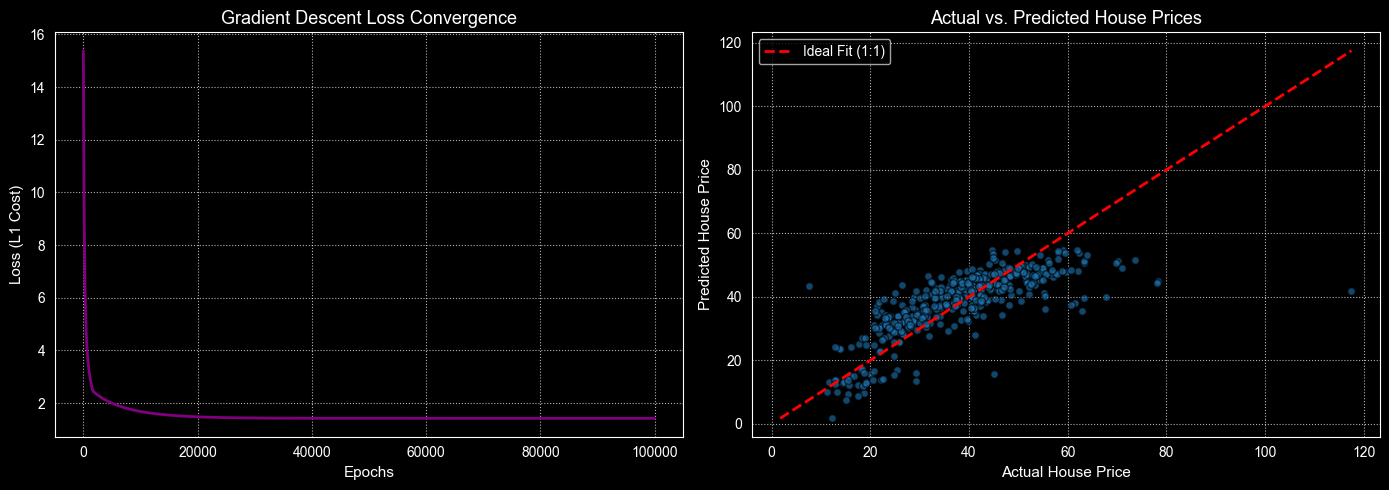

In [79]:
import matplotlib.pyplot as plt

# Generate predictions back on the original scale using normalized features
Y_pred_norm = predict(X_norm, W, b)
Y_pred_original = (Y_pred_norm * np.std(Y)) + np.mean(Y)

# Create a clean two-panel evaluation figure for standard Linear/Lasso Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Convergence Curve
axes[0].plot(losses, color='purple', linewidth=2)
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Loss (L1 Cost)', fontsize=11)
axes[0].set_title('Gradient Descent Loss Convergence', fontsize=13)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Plot 2: Actual vs. Predicted Target Distribution
Y_actual = Y.ravel()
Y_predicted = Y_pred_original.ravel()

axes[1].scatter(Y_actual, Y_predicted, color='#1f77b4', alpha=0.6, edgecolors='k', s=30)
min_val = min(Y_actual.min(), Y_predicted.min())
max_val = max(Y_actual.max(), Y_predicted.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (1:1)')

axes[1].set_xlabel('Actual House Price', fontsize=11)
axes[1].set_ylabel('Predicted House Price', fontsize=11)
axes[1].set_title('Actual vs. Predicted House Prices', fontsize=13)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Polynomial Feature Expansion & External Pipeline Execution
Appending the project directory to Python's path to import custom modules, generating degree-3 polynomial features, standardizing them, and fitting the regression model.

In [23]:
import sys
import os

# Add the root project directory to Python's path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

from PolynomialRegression.poly_model import PolynomialRegression
from LassoRegression import LassoRegression

poly = PolynomialRegression()
poly_features = poly.PolynomialFeatures(X)
poly_features.shape
poly_scaled = (poly_features - np.mean(poly_features,axis = 0,keepdims=True)) / np.std(poly_features,axis = 0,keepdims=True)
lasso = LassoRegression(lamda = 1, learning_rate=0.1, epochs=100000)
lasso.fit(poly_scaled,Y_norm)
lasso.W



Cost after epoch 0: 2.781899659713767
Cost after epoch 50: 0.3854679549624321
Cost after epoch 100: 0.30345366272864754
Cost after epoch 150: 0.2555571213145539
Cost after epoch 200: 0.2262504314750661
Cost after epoch 250: 0.20964492112287178
Cost after epoch 300: 0.19954364339882127
Cost after epoch 350: 0.19342987864573355
Cost after epoch 400: 0.18949468797734892
Cost after epoch 450: 0.18693674384398576
Cost after epoch 500: 0.18525418655832077
Cost after epoch 550: 0.18412938488143868
Cost after epoch 600: 0.183362162406314
Cost after epoch 650: 0.18282379355084966
Cost after epoch 700: 0.1824330083669796
Cost after epoch 750: 0.18213648570893243
Cost after epoch 800: 0.18190152992816924
Cost after epoch 850: 0.18170691825402596
Cost after epoch 900: 0.18153860904665467
Cost after epoch 950: 0.18138778270514921
Cost after epoch 1000: 0.18130102053517766
Cost after epoch 1050: 0.18122692408931204
Cost after epoch 1100: 0.18115723198856246
Cost after epoch 1150: 0.1810916807136658


array([[-2.61398495e-02],
       [ 9.35306557e-02],
       [-7.70508581e-01],
       [-9.86751414e-01],
       [ 3.59574016e-02],
       [ 2.07652071e-05],
       [ 1.27717390e-02],
       [ 3.17911446e-04],
       [ 2.81871310e-02],
       [ 5.55188537e-01],
       [ 6.13856724e-01],
       [ 1.00530363e-01],
       [ 2.22450657e-01],
       [ 1.18554620e-03]])

### 5. Model Evaluation & Visualization
We visualize our trained Lasso Polynomial Regression model by plotting the gradient descent loss convergence over epochs and comparing our actual house prices against the model's predictions.

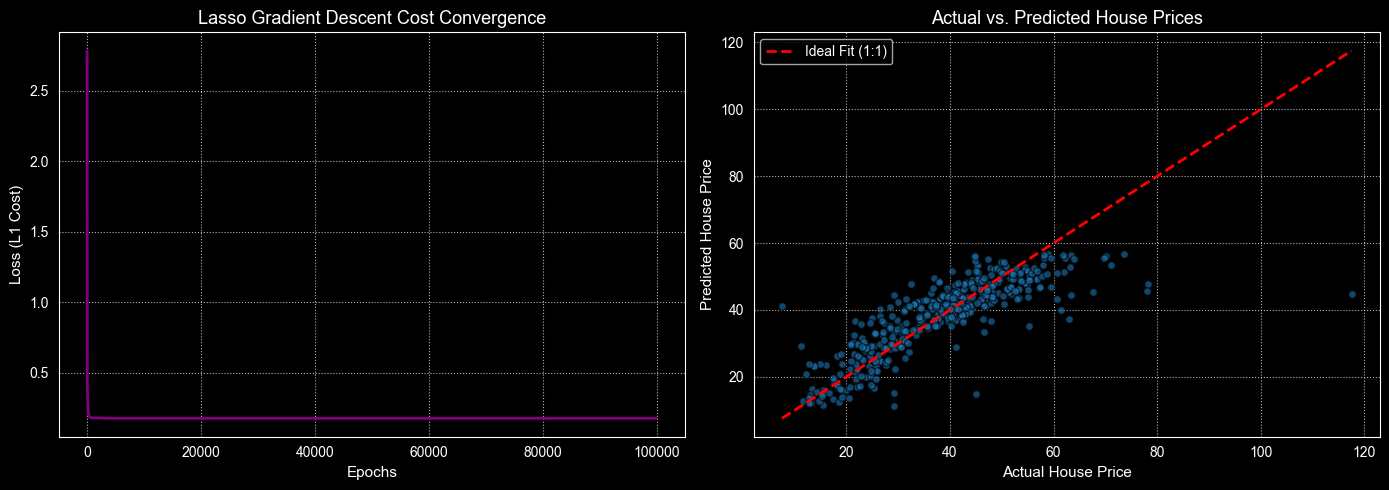

In [28]:
import matplotlib.pyplot as plt

# Generate predictions back on the original scale
Y_pred_lasso = lasso.LinearModel(poly_scaled)
Y_pred_original = (Y_pred_lasso * np.std(Y)) + np.mean(Y)

# Create a clean two-panel evaluation figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Convergence Curve
axes[0].plot(lasso.losses, color='purple', linewidth=2)
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Loss (L1 Cost)', fontsize=11)
axes[0].set_title('Lasso Gradient Descent Cost Convergence', fontsize=13)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Plot 2: Actual vs. Predicted Target Distribution
Y_actual = Y.ravel()
Y_predicted = Y_pred_original.ravel()

axes[1].scatter(Y_actual, Y_predicted, color='#1f77b4', alpha=0.6, edgecolors='k', s=30)
min_val = min(Y_actual.min(), Y_predicted.min())
max_val = max(Y_actual.max(), Y_predicted.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (1:1)')

axes[1].set_xlabel('Actual House Price', fontsize=11)
axes[1].set_ylabel('Predicted House Price', fontsize=11)
axes[1].set_title('Actual vs. Predicted House Prices', fontsize=13)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()